In [4]:
import cv2
from doclayout_yolo import YOLOv10
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import PIL 
#from kalchas.image_utils import #nlbin

In [5]:
!ls -lah /Users/konstantinosperifanos/Downloads/doclayout_yolo_docstructbench_imgsz1024.pt

-rw-r--r--@ 1 konstantinosperifanos  staff    39M Oct 21 21:47 /Users/konstantinosperifanos/Downloads/doclayout_yolo_docstructbench_imgsz1024.pt


In [6]:
model  = YOLOv10("/Users/konstantinosperifanos/Downloads/doclayout_yolo_docstructbench_imgsz1024.pt")

/Users/konstantinosperifanos/code/venvs/py3/lib/python3.10/site-packages/doclayout_yolo/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file

In [7]:
original_image = "/Users/konstantinosperifanos/code/projects/kalchas/streamlitsrv/st/uploads/2202.00666/000.png"
original_image = "/Users/konstantinosperifanos/Downloads/pages/ΑΑ/pngs/Αλληλογραφία/0.png"
original_image = "/Users/konstantinosperifanos/Downloads/pages/ΑΑ/pngs/Η ορειβασία εξεταζομένη υπό υγειινή άποψη/0.png"

original_image = "/Users/konstantinosperifanos/Downloads/pages/ΑΑ/pngs/Παροράματα/0.png" 

original_image = "/Users/konstantinosperifanos/Downloads/pages/ΑΑ/pngs/Δελτίον της Αθηναιδος ευεργετήματα της αγγλικής διοικήσεως/0.png"

original_image = "/Users/konstantinosperifanos/Downloads/pages/TODO/Kostas/TODO/1854 -Κατοχή Μαύρης θάλασσας/backup/000.png"

In [ ]:
original_image_pil = PIL.Image.open(original_image).convert('L')
#binary_img = original_image_pil.point(lambda x: 0 if x < 128 else 255, '1')

In [31]:

# Perform prediction
det_res = model.predict(
    original_image_pil,   # Image to predict
    imgsz=1024,        # Prediction image size
    conf=0.35,          # Confidence threshold
    device="mps"    # Device to use (e.g., 'cuda:0' or 'cpu')
)

# Annotate and save the result
annotated_frame = det_res[0].plot(pil=True, line_width=5, font_size=20)
cv2.imwrite("result.jpg", annotated_frame)




0: 1024x736 1 plain text, 3 figures, 257.9ms
Speed: 326.8ms preprocess, 257.9ms inference, 56.7ms postprocess per image at shape (1, 3, 1024, 736)


True

In [32]:

image = PIL.Image.open( original_image)
np_image = np.array(image)
np_image.shape

(3508, 2480)

In [33]:
class_names = det_res[0].names

In [34]:
coords = []
for box_idx in range(len(det_res[0].boxes)):
    
    box =  det_res[0].boxes[box_idx] 
    x1, y1, x2, y2 = [ int(_) for _ in box.xyxy[0].cpu().numpy().tolist()]
    cls_name = class_names[box.cls.item()]#
    #,x1, y1, x2, y2
    #if cls_name == 'abandon':
    #    continue

    coords.append( (y1,x1, y2, x2, cls_name ) )

    crop = np_image[  y1:y2, x1:x2]
    #plt.imshow( crop)
    #plt.show()

df = pd.DataFrame( data = coords, columns= ["y1", "x1", "y2", "x2", "cls_name"])



In [35]:
df.sort_values(by = ["y1","x1"], inplace=True)
df

,y1,x1,y2,x2,cls_name
2,297,375,656,2078,figure
1,730,390,1878,2089,figure
3,730,390,1878,2089,plain text
0,1915,379,2687,2100,figure


figure


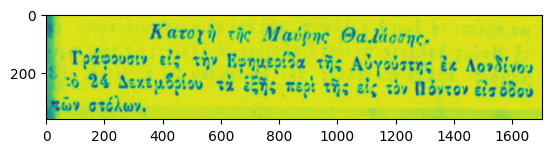

figure


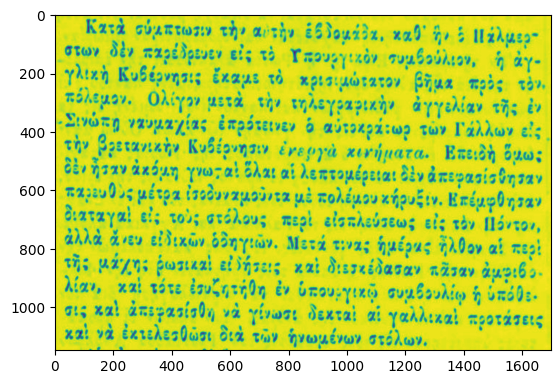

plain text


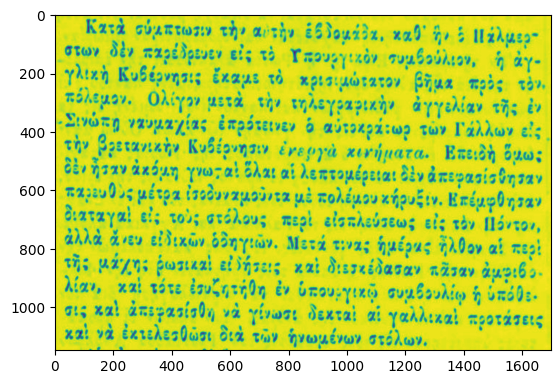

figure


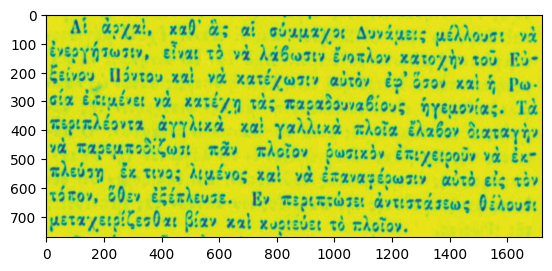

In [40]:
for idx, row in df.iterrows():

    y1,x1, y2, x2, cls_name = row 
    print( cls_name)
    crop = np_image[  y1:y2, x1:x2]
    plt.imshow( crop)
    plt.show()
    

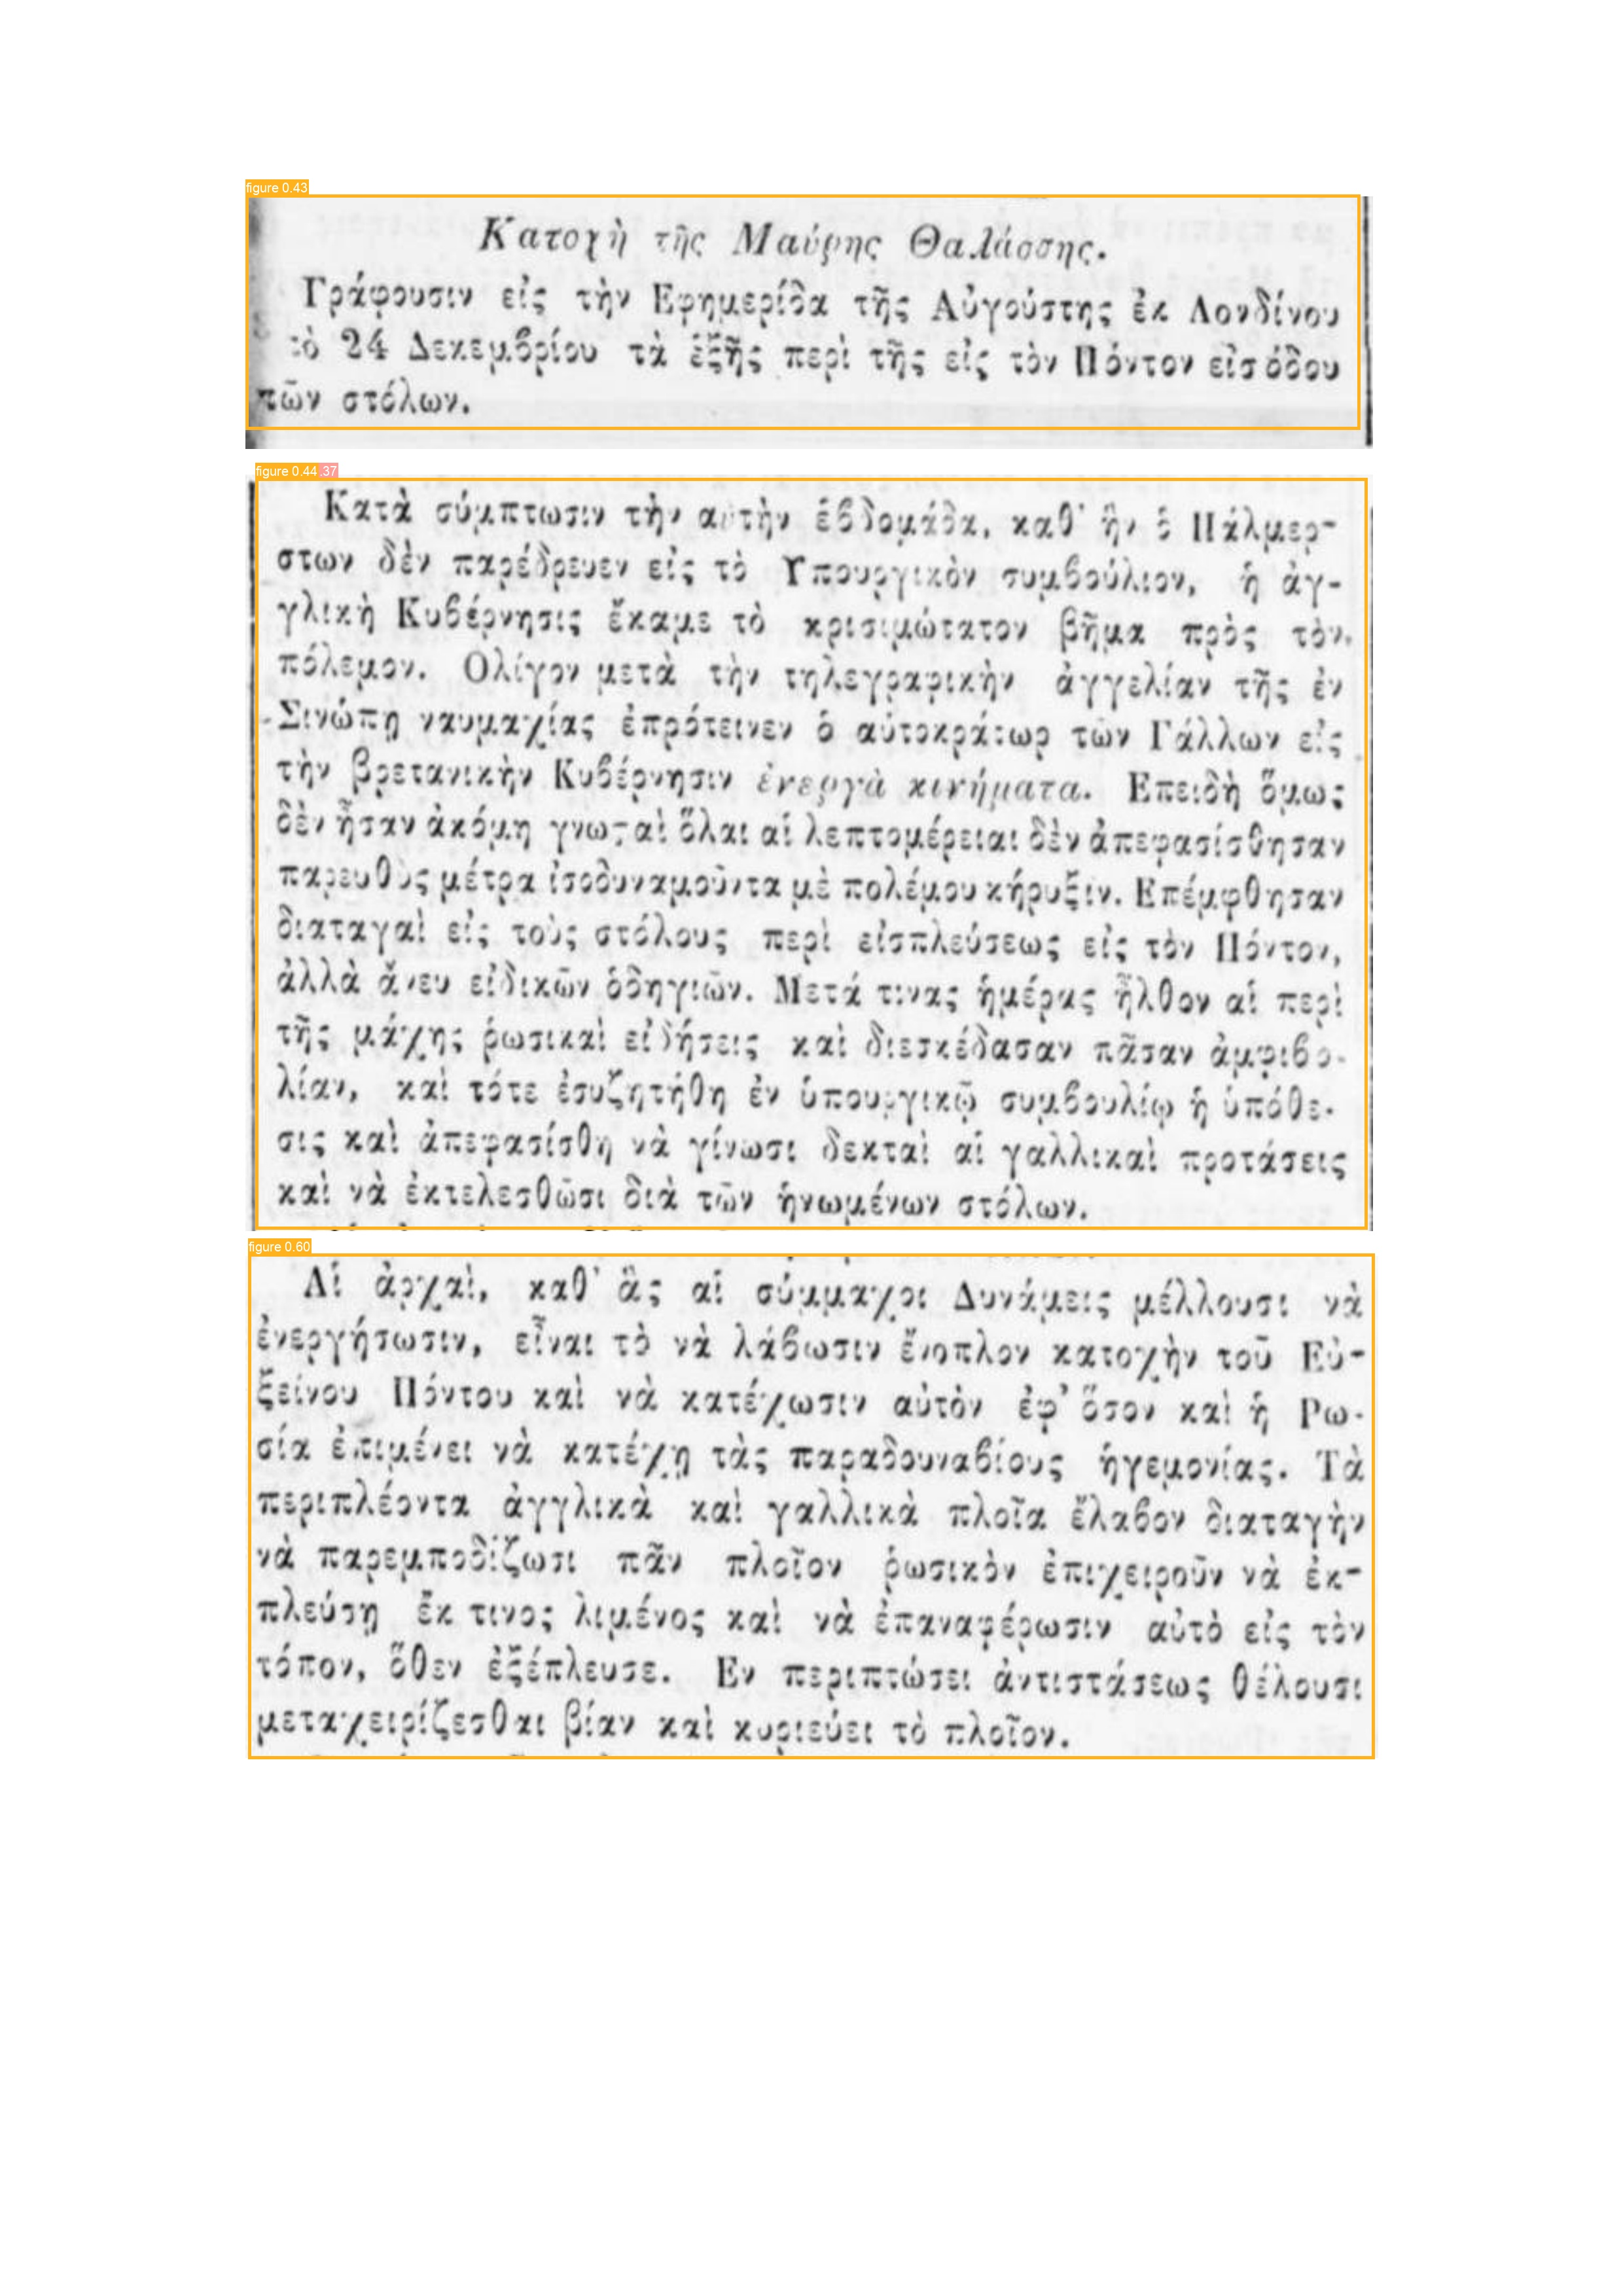

In [37]:
PIL.Image.open("result.jpg")

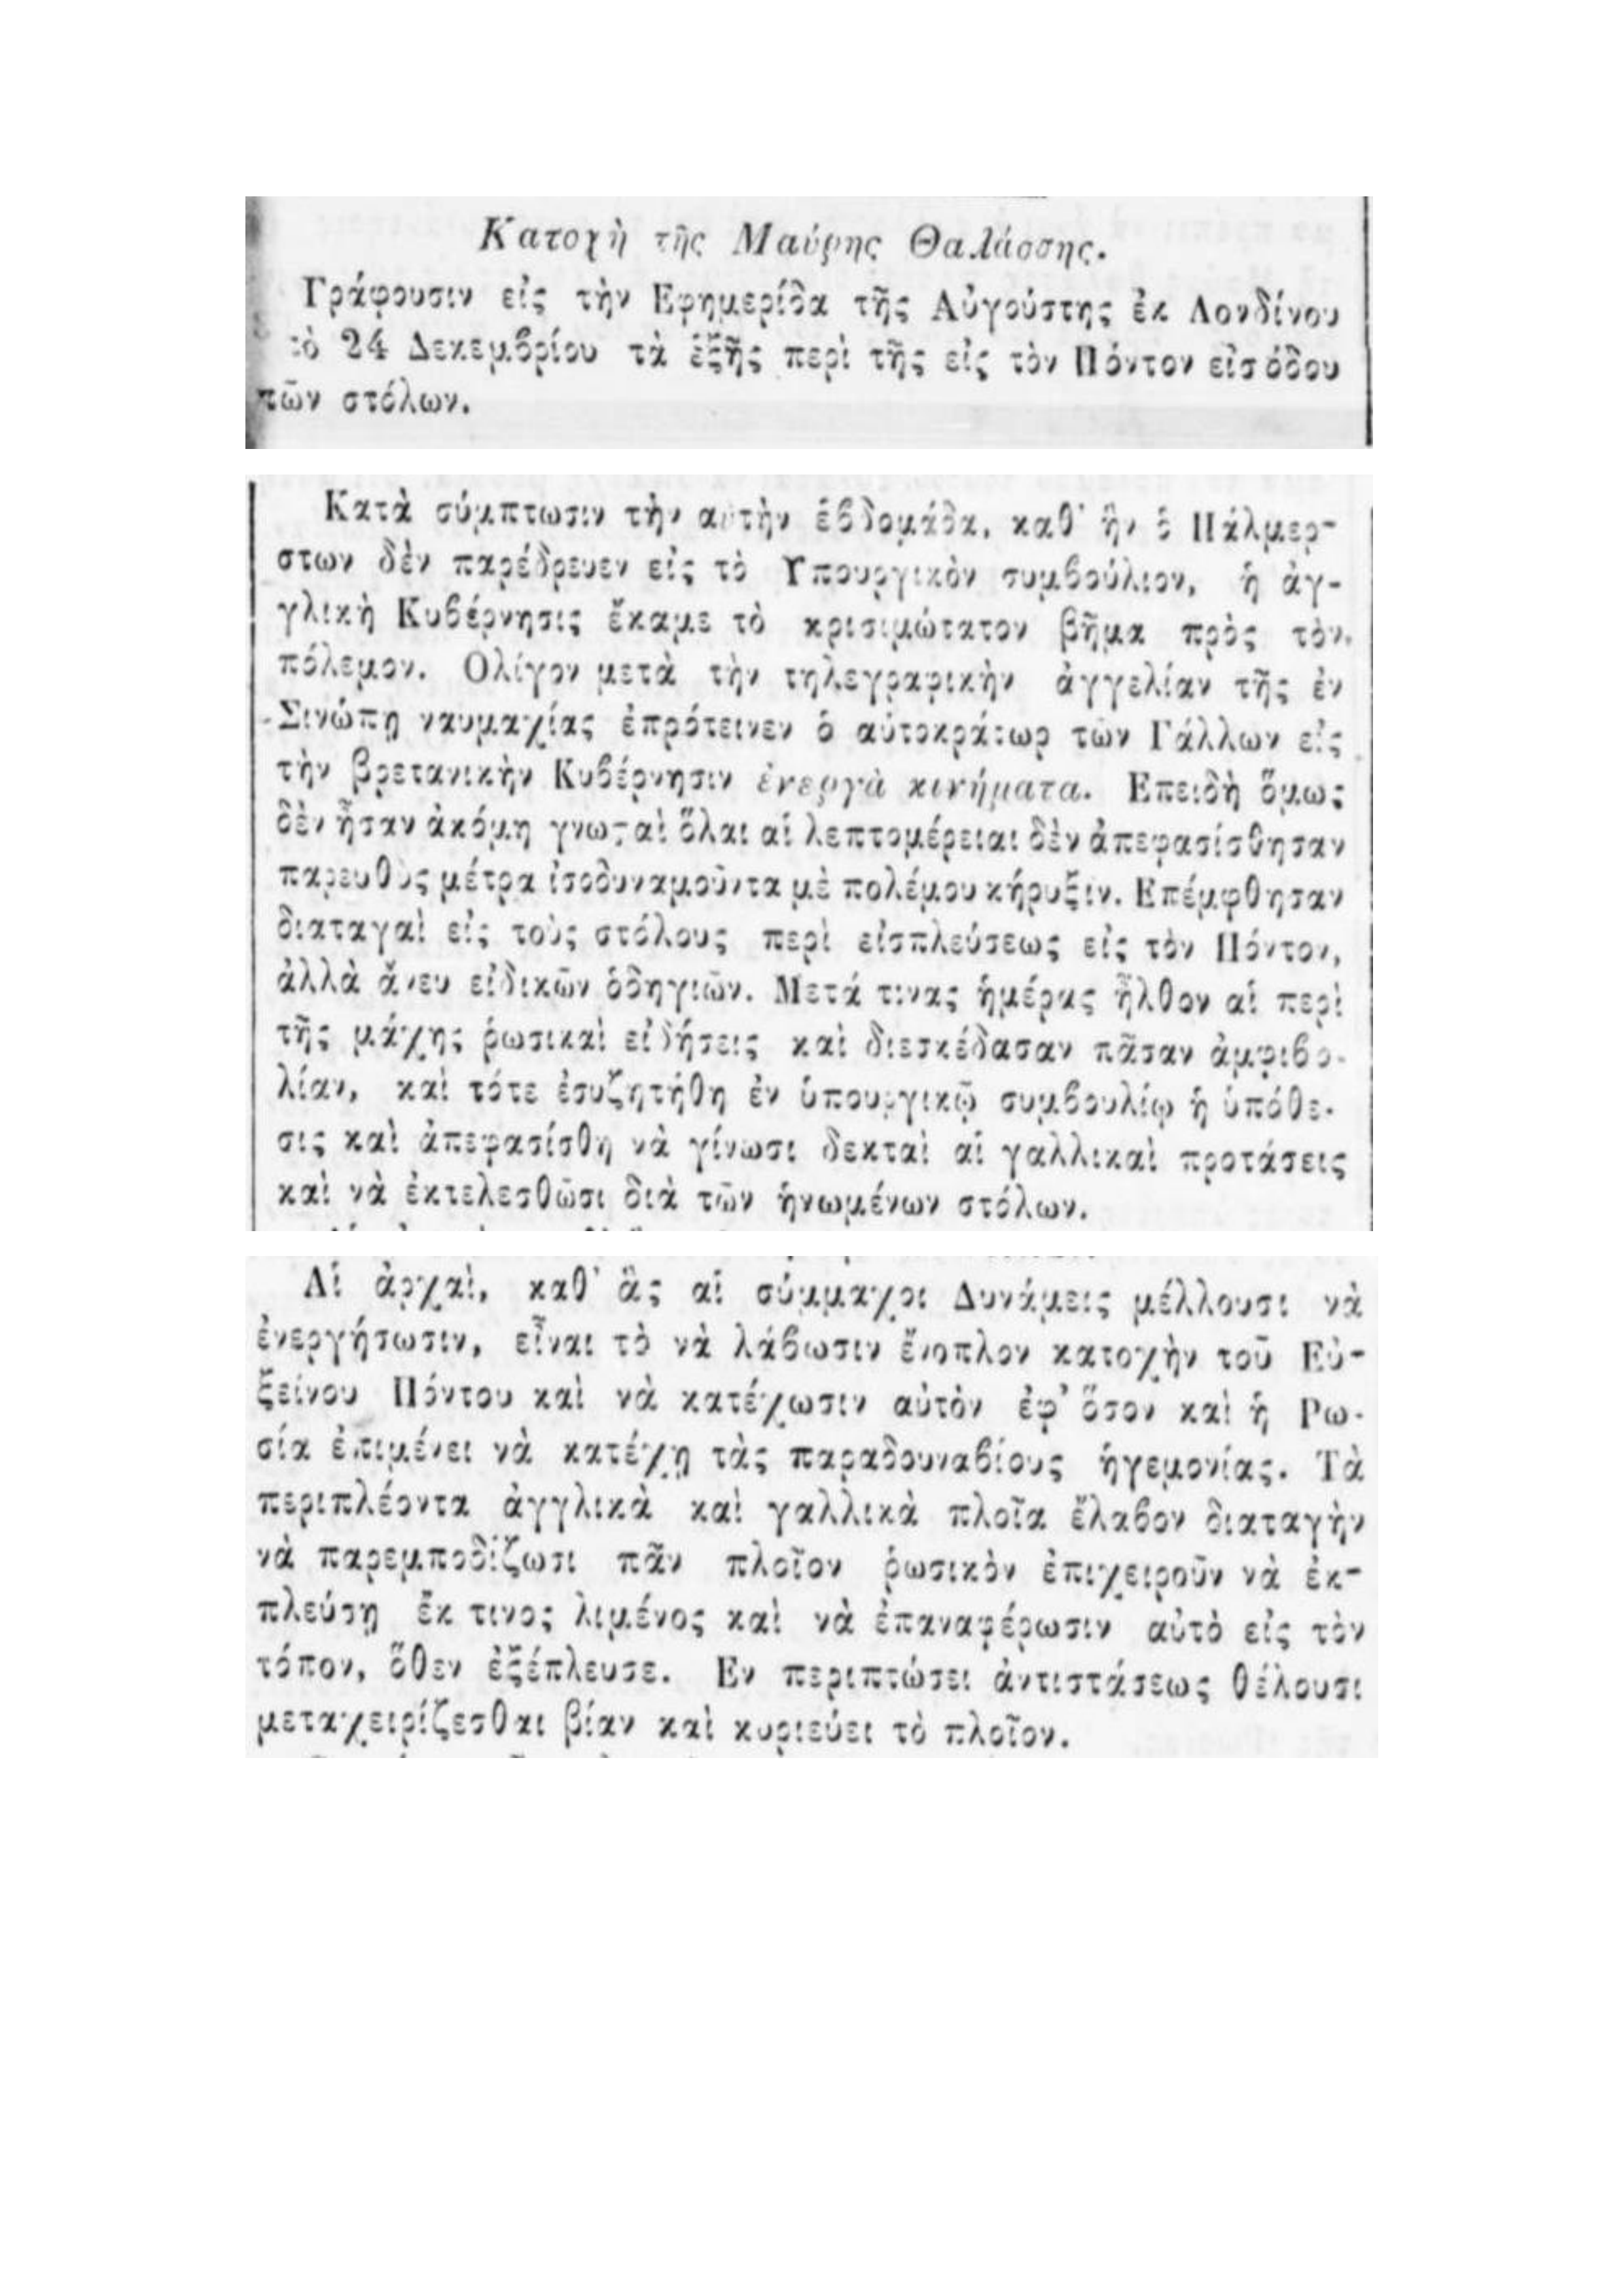

In [38]:
image

In [28]:
coords

[(1915, 379, 2687, 2100, 'figure')]

In [29]:
sorted( coords, key=lambda k: (k[0], k[1]) )

[(1915, 379, 2687, 2100, 'figure')]

In [30]:
df

,y1,x1,y2,x2,cls_name
0,1915,379,2687,2100,figure
